<a href="https://colab.research.google.com/github/siddhisalkar2005/CSL701-CE40_Machine-Learning-Lab/blob/main/Experimentsmlexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Siddhi Salkar Roll No:CE40

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("auto-mpg (1).csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.shape

(398, 9)

In [7]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [9]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [10]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [11]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df = df.dropna()

In [12]:
df = df[['horsepower', 'mpg']]

df.head()

,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0


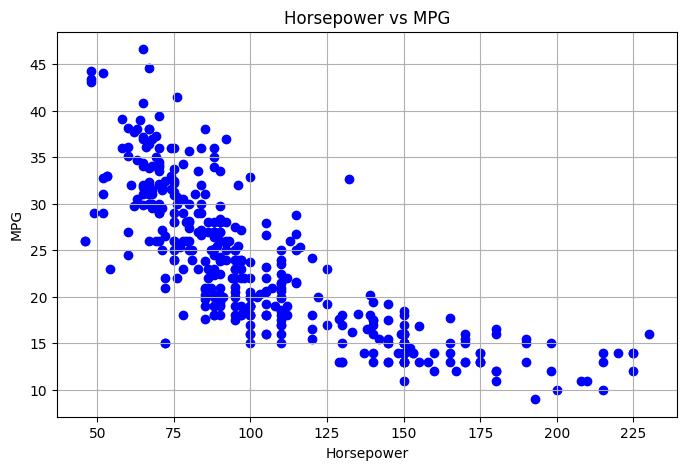

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df['horsepower'], df['mpg'], color='blue')

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.grid(True)

plt.show()

In [14]:
import numpy as np

X = df['horsepower'].values.reshape(-1,1)
Y = df['mpg'].values

# Add a column of ones (bias/intercept)
ones = np.ones((X.shape[0], 1))
X_bias = np.hstack((ones, X))

print(X_bias[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [15]:
correlation = df['horsepower'].corr(df['mpg'])

print("Correlation =", correlation)

Correlation = -0.7784267838977756


In [16]:
W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept (w0) =", W[0])
print("Slope (w1) =", W[1])

Intercept (w0) = 39.9358610211705
Slope (w1) = -0.15784473335365387


In [17]:
Y_pred = X_bias @ W

print("First 10 Predicted Values:")
print(Y_pred[:10])

First 10 Predicted Values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [18]:
Residuals = Y - Y_pred

print("First 10 Residuals:")
print(Residuals[:10])

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [19]:
SSE = np.sum((Y - Y_pred) ** 2)

print("SSE =", SSE)

SSE = 9385.915871932419


In [20]:
MSE = np.mean((Y - Y_pred) ** 2)

print("MSE =", MSE)

MSE = 23.943662938603108


In [21]:
SST = np.sum((Y - np.mean(Y)) ** 2)

R2 = 1 - (SSE / SST)

print("R² =", R2)

R² = 0.6059482578894348


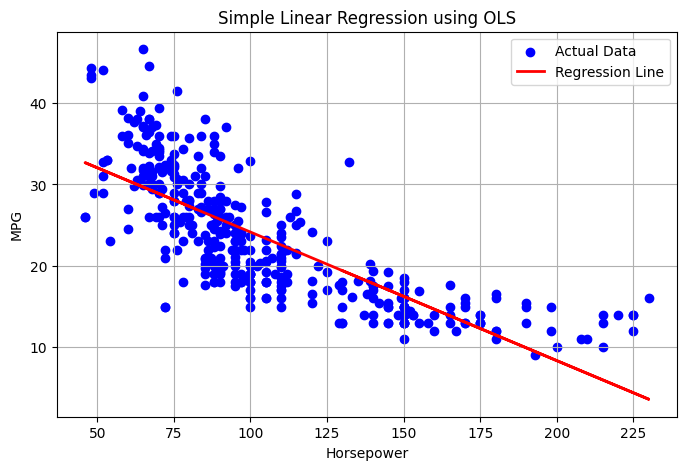

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(X, Y, color='blue', label='Actual Data')

plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression using OLS")

plt.legend()

plt.grid(True)

plt.show()

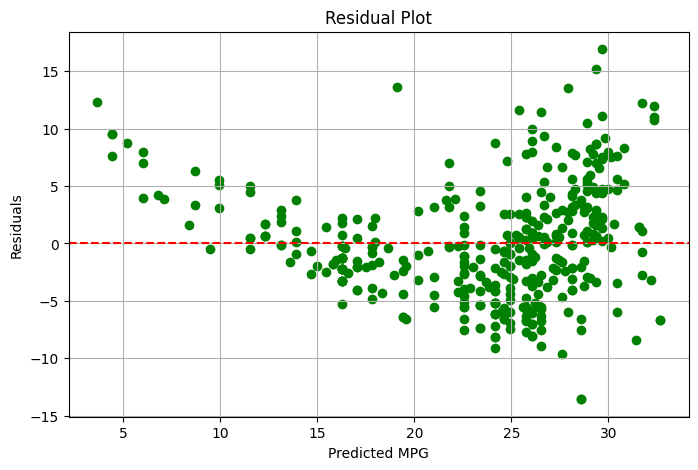

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(Y_pred, Residuals, color='green')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()